In [1]:
from utils import load_all_games_csv, load_batting_csv
from elos import EloTracker
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from scipy.stats import norm

# Elo difference vs Hit %

This notebook focus on the relationship, for each player, between the difference in their team vs opponent team Elo and hit % for the last 5 seasons (2021-25).

## Get all Games and Add Elos

In [2]:
all_games = load_all_games_csv(preprocess=True).reset_index()
#all_games = all_games[(all_games['season'] >= 1990) & (all_games['season'] < 2000)]
all_games.head()

/Users/lancehendricks/Documents/College Coding/ML/Elo Ratings/analysis/src/utils/misc_utils.py:33: DtypeWarning: Columns (10,11,13,17,19,20,21,27,28) have mixed types. Specify dtype option on import or set low_memory=False.
  all_games = pd.read_csv(data_dir / filename)


,gid,visteam,hometeam,site,date,number,starttime,daynight,innings,tiebreaker,...,vispitcherminusteamrgs,homefirstpitchergameofseason,visfirstpitchergameofseason,homelastkwinpct,vislastkwinpct,adjustedvisrestdays,adjustedhomerestdays,adjustedhomedistancetraveled,adjustedvisdistancetraveled,adjustedmarginofvictory
0,CIN189804150,CL4,CIN,CIN05,18980415,0.0,0:00PM,day,NaN,NaN,...,0.0,True,True,NaN,NaN,3.0,3.0,0.0,6.081473,1.000000
1,LS3189804150,PIT,LS3,LOU03,18980415,0.0,0:00PM,day,NaN,NaN,...,0.0,True,True,NaN,NaN,3.0,3.0,0.0,7.010260,2.645751
2,SLN189804150,CHN,SLN,STL05,18980415,0.0,0:00PM,day,NaN,NaN,...,0.0,True,True,NaN,NaN,3.0,3.0,0.0,6.375653,1.000000
3,BLN189804160,WSN,BLN,BAL07,18980416,0.0,0:00PM,day,NaN,NaN,...,0.0,True,True,NaN,NaN,3.0,3.0,0.0,3.278478,2.236068
4,CIN189804160,CL4,CIN,CIN05,18980416,0.0,0:00PM,day,NaN,NaN,...,-25.9,True,True,1.0,0.0,1.0,1.0,0.0,0.000000,1.414214


In [3]:
et = EloTracker()
et.add_history(all_games, add_elos_to_df=True)

In [4]:
all_games = all_games[all_games['season'] >= 2021]
all_games.head()

,gid,visteam,hometeam,site,date,number,starttime,daynight,innings,tiebreaker,...,vislastkwinpct,adjustedvisrestdays,adjustedhomerestdays,adjustedhomedistancetraveled,adjustedvisdistancetraveled,adjustedmarginofvictory,homeelobefore,viselobefore,homeeloafter,viseloafter
209984,ANA202104010,CHA,ANA,ANA01,20210401,0.0,7:05PM,night,9.0,2.0,...,NaN,3.0,3.0,0.0,12.007542,1.000000,1488.714680,1493.735424,1490.236355,1492.213749
209985,CHN202104010,PIT,CHN,CHI11,20210401,0.0,1:20PM,day,9.0,2.0,...,NaN,3.0,3.0,0.0,7.434099,1.414214,1508.674014,1471.668137,1507.014848,1473.327303
209986,CIN202104010,SLN,CIN,CIN09,20210401,0.0,4:10PM,day,9.0,2.0,...,NaN,3.0,3.0,0.0,6.750681,2.236068,1491.977577,1508.525114,1490.548965,1509.953726
209987,COL202104010,LAN,COL,DEN02,20210401,0.0,2:10PM,day,9.0,2.0,...,NaN,3.0,3.0,0.0,8.681162,1.732051,1488.225311,1550.499278,1489.991327,1548.733263
209988,DET202104010,CLE,DET,DET05,20210401,0.0,1:10PM,day,9.0,2.0,...,NaN,3.0,3.0,0.0,4.500164,1.000000,1455.099180,1515.133258,1456.855819,1513.376619


## Get Individual Batting Data and join to all_games

In [5]:
batting = load_batting_csv().reset_index()
batting = batting[batting['season'] >= 2021]
cols = ['gid', 'id', 'team', 'b_h', 'b_ab']
batting = batting[cols]
batting.head()

/Users/lancehendricks/Documents/College Coding/ML/Elo Ratings/analysis/src/utils/misc_utils.py:55: DtypeWarning: Columns (38) have mixed types. Specify dtype option on import or set low_memory=False.
  batting = pd.read_csv(data_dir / filename)


,gid,id,team,b_h,b_ab
5382978,ANA202104010,andet001,CHA,1.0,4.0
5382979,ANA202104010,eatoa002,CHA,1.0,4.0
5382980,ANA202104010,abrej003,CHA,1.0,4.0
5382981,ANA202104010,moncy001,CHA,2.0,3.0
5382982,ANA202104010,grany001,CHA,0.0,3.0


In [21]:
games_batting_home = pd.merge(all_games, batting, how='left', left_on=['gid', 'hometeam'], right_on=['gid', 'team'])
games_batting_away = pd.merge(all_games, batting, how='left', left_on=['gid', 'visteam'], right_on=['gid', 'team'])
games_batting = pd.concat([games_batting_home, games_batting_away], ignore_index=True)

In [22]:
games_batting.head()

,gid,visteam,hometeam,site,date,number,starttime,daynight,innings,tiebreaker,...,adjustedvisdistancetraveled,adjustedmarginofvictory,homeelobefore,viselobefore,homeeloafter,viseloafter,id,team,b_h,b_ab
0,ANA202104010,CHA,ANA,ANA01,20210401,0.0,7:05PM,night,9.0,2.0,...,12.007542,1.0,1488.71468,1493.735424,1490.236355,1492.213749,fletd002,ANA,1.0,4.0
1,ANA202104010,CHA,ANA,ANA01,20210401,0.0,7:05PM,night,9.0,2.0,...,12.007542,1.0,1488.71468,1493.735424,1490.236355,1492.213749,ohtas001,ANA,0.0,4.0
2,ANA202104010,CHA,ANA,ANA01,20210401,0.0,7:05PM,night,9.0,2.0,...,12.007542,1.0,1488.71468,1493.735424,1490.236355,1492.213749,troum001,ANA,1.0,2.0
3,ANA202104010,CHA,ANA,ANA01,20210401,0.0,7:05PM,night,9.0,2.0,...,12.007542,1.0,1488.71468,1493.735424,1490.236355,1492.213749,renda001,ANA,1.0,3.0
4,ANA202104010,CHA,ANA,ANA01,20210401,0.0,7:05PM,night,9.0,2.0,...,12.007542,1.0,1488.71468,1493.735424,1490.236355,1492.213749,uptoj001,ANA,1.0,3.0


## Get Final DataFrame containing Player, Elo Difference Bin and %

In [31]:
norm.cdf(-20, loc=0, scale=30)

0.2524925375469229

In [32]:
def elo_diff_to_bin(elo_diff):
    if elo_diff < -20:
        return '(-inf,-20)'
    elif elo_diff < 0:
        return '[-20,0)'
    elif elo_diff < 20:
        return '[0,20)'
    else:
        return '[20,inf)'

In [42]:
cols = ['team', 'id', 'b_h', 'b_ab', 'elo_diff_binned']

df_home = games_batting[games_batting['hometeam'] == games_batting['team']]
df_home['elo_diff_binned'] = (df_home['homeelobefore'] - df_home['viselobefore']).apply(elo_diff_to_bin)
df_home = df_home[cols]

df_away = games_batting[games_batting['visteam'] == games_batting['team']]
df_away['elo_diff_binned'] = (df_away['viselobefore'] - df_away['homeelobefore']).apply(elo_diff_to_bin)
df_away = df_away[cols]

final_df = pd.concat([df_home, df_away]).groupby(by=['team', 'id', 'elo_diff_binned']).agg({'b_h':'sum', 'b_ab':'sum'}).reset_index()
final_df['elo_diff_binned_numeric'] = final_df['elo_diff_binned'].map({'(-inf,-20)':0, '[-20,0)':1, '[0,20)':2, '[20,inf)':3})
final_df['hit_pct'] = final_df['b_h'] / final_df['b_ab']
final_df.head()

/var/folders/f3/w3vlb72x47z3vhjsm9s6jlxc0000gn/T/ipykernel_36062/3778950891.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_home['elo_diff_binned'] = (df_home['homeelobefore'] - df_home['viselobefore']).apply(elo_diff_to_bin)
/var/folders/f3/w3vlb72x47z3vhjsm9s6jlxc0000gn/T/ipykernel_36062/3778950891.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_away['elo_diff_binned'] = (df_away['viselobefore'] - df_away['homeelobefore']).apply(elo_diff_to_bin)


,team,id,elo_diff_binned,b_h,b_ab,elo_diff_binned_numeric,hit_pct
0,ANA,adamj003,"(-inf,-20)",11.0,52.0,0,0.211538
1,ANA,adamj003,"[-20,0)",0.0,3.0,1,0.000000
2,ANA,adamj003,"[0,20)",0.0,7.0,2,0.000000
3,ANA,adamj003,"[20,inf)",2.0,12.0,3,0.166667
4,ANA,adelj001,"(-inf,-20)",204.0,925.0,0,0.220541


## See Relationship between Elo difference and %

<Axes: xlabel='elo_diff_binned_numeric', ylabel='hit_pct'>

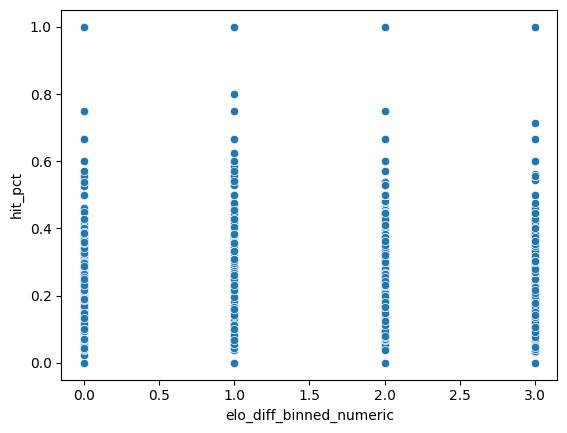

In [43]:
sns.scatterplot(data=final_df, x='elo_diff_binned_numeric', y='hit_pct')

In [44]:
lr = LinearRegression()
lr.fit(final_df['elo_diff_binned_numeric'].to_numpy().reshape(-1,1), final_df['hit_pct'].to_numpy().reshape(-1,1))
slope = lr.coef_[0]
intercept = lr.intercept_
print("Slope:",slope)
print("Intercept:",intercept)

ValueError: Input y contains NaN.